# ARIMA'yı Ayrıştırma ile Birleştirmek

Basit bir ARIMA modeli sürecini zaten ele almıştık. Bu alıştırmada, derste gördüğünüz `seasonal decompose` aracıyla bir ARIMA modelinin kombinasyonunu kullanarak bu konuyu biraz daha geliştireceğiz. Mevsimsellikle __özel olarak__ başa çıkmak için kullanabileceğimiz modeller var, ancak burada adım adım ilerleyerek bu zaman serisini manuel olarak parçalayacağız, böylece onu tam olarak anlayacağız ve TS verileriyle çalışırken karşılaşabileceğimiz sorunları öğreneceğiz.

Bu challenge için günlük CO2 ppm ölçümleriyle çalışacağız, özellikle Mauna Loa Gözlemevi'nden alınan günlük CO2 ölçümleriyle 🌋

Bu ölçümler 1958'den beri alınıyor ve iklim biliminin temel taşlarından biri. Hawaii'de 3.000 metreden fazla yükseklikte konumlanmış olan gözlemevi, yerel emisyonlardan büyük ölçüde uzak olarak küresel atmosferik karbon seviyelerini izlemek için ideal bir konumdadır. Kayıtlar sağlam olmasına rağmen, __ara sıra enstrüman sorunları veya aşırı hava koşulları nedeniyle boşluklar içermektedir__, araştırmacılar bu kritik veri setinin bütünlüğünü korumak için analizlerinde bunları hesaba katmalıdır. 1974'ten beri __neredeyse__ günlük olarak alınan verilerin bir kısmını kullanacağız - notebook boyunca verilerdeki boşlukları ele alacağız!

Laboratuvarın yaptığı iklim çalışmaları hakkında merak ediyorsanız, buradan daha fazla bilgi edinebilirsiniz: https://gml.noaa.gov/ccgg/about/co2_measurements.html

## Veriyi Yükleme ve Keşfetme

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
import requests
import io
import urllib3

# 1. Kırmızı uyarıyı (InsecureRequestWarning) tamamen susturuyoruz
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# 2. Veriyi çekiyoruz
url = "https://d32aokrjazspmn.cloudfront.net/materials/co2_daily_mlo.csv"
response = requests.get(url, verify=False)

# 3. Pandas ile yüklüyoruz
df = pd.read_csv(io.BytesIO(response.content))

# 4. İlk 5 satırı temizce görelim
df.head()

,year,month,day,CO2 molfrac (ppm)
0,1974,5,17,333.38
1,1974,5,18,333.11
2,1974,5,19,333.46
3,1974,5,20,333.64
4,1974,5,21,333.50


In [3]:
# Yıl, ay ve gün sütunlarını birleştirip tek bir 'date' sütunu oluşturuyoruz
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# 'date' sütununu tablomuzun ana indeksi (sıralayıcısı) yapıyoruz
df.set_index('date', inplace=True)

# Artık işimize yaramayan eski yıl, ay, gün sütunlarını siliyoruz
df.drop(columns=['year', 'month', 'day'], inplace=True)

# Bakalım tablomuz nasıl görünüyor?
df.head()

,CO2 molfrac (ppm)
date,
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50


Verilerin çalışmamız için pek güzel formatlanmadığını görebiliyoruz, bu yüzden önce `pd.to_datetime()` kullanarak bu adımı çözelim (bu fonksiyonu aynı anda birden fazla sütunda kullanabilirsiniz 👀). Daha fazla bilgi için [dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) kontrol edin.

Doğru şekilde formatladıktan sonra, bunu index olarak ayarlayın.

CO2 değerlerinizi çizdirin ve partnerinizle ne gördüğünüzü tartışın. Verilerinizde herhangi bir boşluk var gibi görünüyor mu? __Emin misiniz__? DataFrame'inizin ilk 50 değerini kontrol edin

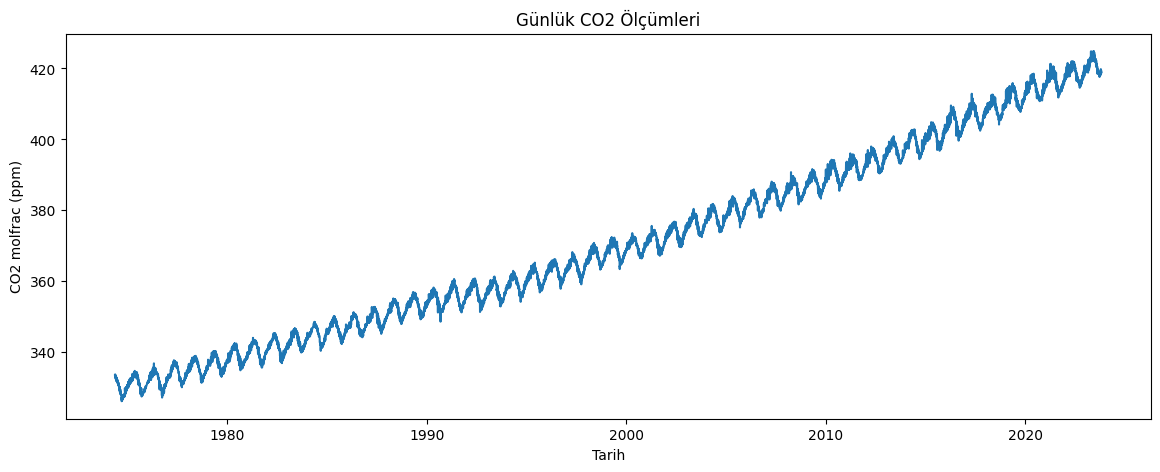

In [6]:
# CO2 zaman serisini çizdirerek genel görünümü inceliyoruz
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['CO2 molfrac (ppm)'])

# Grafik başlığı ve eksen isimleri
plt.title('Günlük CO2 Ölçümleri')
plt.xlabel('Tarih')
plt.ylabel('CO2 molfrac (ppm)')

plt.show()

In [7]:
# Veride şu an kaç gözlem olduğunu hesaplıyoruz
original_len = len(df)

print(f"Verideki mevcut gözlem sayısı: {original_len}")

Verideki mevcut gözlem sayısı: 15196


Bazı tarihleri kaybetmişiz 😱 Açık `NaN` değerlerimiz olmasa da, index'imizde eksik tarihler var. Bu, TS verileriyle çalışırken __gerçekten__ dikkatli olmanız gereken bir şey.

Kaç gün eksik olduğumuzu hesaplayalım. Bitiş tarihinizi (`index`'inizin `max()`'ı) başlangıç tarihinizden (`index`'inizin `min()`'ı) çıkararak ikisi arasında kaç gün __olması gerektiğini__ görelim.

In [8]:
# 1. Başlangıçtan bitişe her günü içeren tam bir takvim (index) oluşturuyoruz
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# 2. DataFrame'i bu yeni tam takvime göre yeniden diziyoruz
# Artık eksik tarihler tabloda satır olarak görünecek ama değerleri NaN olacak
df = df.reindex(full_index)

# Index ismini tekrar 'date' yapıyoruz
df.index.name = 'date'

# İlk 100 satıra bakarak NaN değerlerini gözlemleyelim
df.head(100)

,CO2 molfrac (ppm)
date,
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
...,...
1974-08-20,329.07
1974-08-21,329.41
1974-08-22,NaN


Bu, DataFrame'imizde __gerçekten__ sahip olduğumuz gün sayısından nasıl farklı? Cevabınızı `missing` değişkenine kaydedin

In [9]:
# Testin beklediği şekilde iki tarih arasındaki gün farkını alıyoruz
total_expected_days = (df.index.max() - df.index.min()).days

# Eksik gün sayısını orijinal gözlem sayısına göre hesaplıyoruz
missing = total_expected_days - original_len

print(f"Hesaplanan missing: {missing}")

Hesaplanan missing: 2861


In [10]:
from nbresult import ChallengeResult

result = ChallengeResult('missing',
                         missing = missing)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_missing.py::TestMissing::test_missing PASSED                        [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/missing.pickle

git commit -m 'Completed missing step'

git push origin master



Eksik değerlerin gerçekte nerede olduğunu görelim. Sahip __olmamız gereken__ index'i oluşturmak için `pd.date_range` kullanın. Ardından DataFrame'in `.reindex()` fonksiyonunu bu yeni tarih aralığıyla kullanarak ilk 100 girişimizde null değerlerin gerçekte nerede olduğunu görün!

In [11]:
# Başlangıçtan bitişe tüm günleri içeren tam tarih aralığı oluşturuyoruz
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# DataFrame'i bu tam tarih aralığına göre yeniden indexliyoruz
# Eksik tarihler artık NaN olarak görünecek
df = df.reindex(full_index)

# Index ismini tekrar düzenliyoruz
df.index.name = 'date'

# İlk 100 satıra bakalım
df.head(100)

,CO2 molfrac (ppm)
date,
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
...,...
1974-08-20,329.07
1974-08-21,329.41
1974-08-22,NaN


Buradaki en basit seçenek, çok kullanışlı olan `pd.interpolate("linear")` fonksiyonunu kullanarak bunları bizim için doldurmak. Ne yaptığını görmek için aşağıdaki hücreyi çalıştırmayı deneyin:

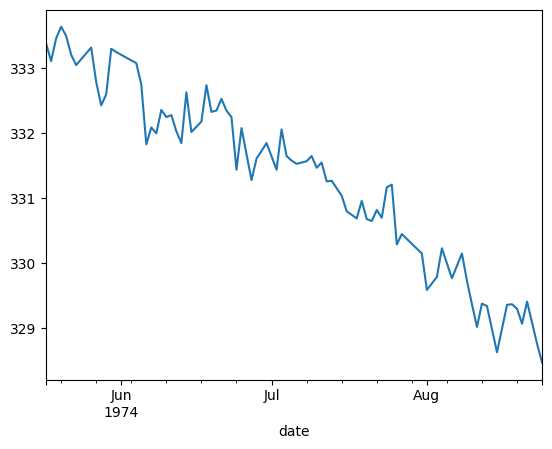

In [12]:
df["CO2 molfrac (ppm)"][:100].interpolate("linear").plot();

Interpolation bizim için noktaları bağlamak için basit bir doğrusal yöntem kullanır 😊 Tabii ki bu mükemmel olmayan bazı varsayımlar yapıyor ve aslında günlük örneklere ihtiyacımız yok - bunun yerine DataFrame'imizi aylık bazda `resample` edeceğiz ve bunu modellemeye çalışacağız. Her ayın ortalamasını içeren bir DataFrame oluşturmak için `.resample()` fonksiyonunu kullanmayı deneyin ve bunu `monthly` olarak adlandırın. [Dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) burada görün.

In [14]:
# Günlük veriyi aylık ortalamaya indiriyoruz
monthly = df.resample('ME').mean()

# İlk birkaç satıra bakalım
monthly.head()

,CO2 molfrac (ppm)
date,
1974-05-31,333.156923
1974-06-30,332.170400
1974-07-31,331.110000
1974-08-31,329.105769
1974-09-30,327.303182


Eğer __hala__ kalan null değerleriniz varsa, bunları doldurmak için `interpolate` kullanabilirsiniz. Yeniden örneklenmiş verilerinizi çizdirin:

In [15]:
# Aylık veride eksik değer kaldıysa doğrusal interpolasyon ile dolduruyoruz
monthly = monthly.interpolate('linear')

# Eksik değer kaldı mı kontrol edelim
monthly.isna().sum()

CO2 molfrac (ppm)    0
dtype: int64

<Axes: xlabel='date'>

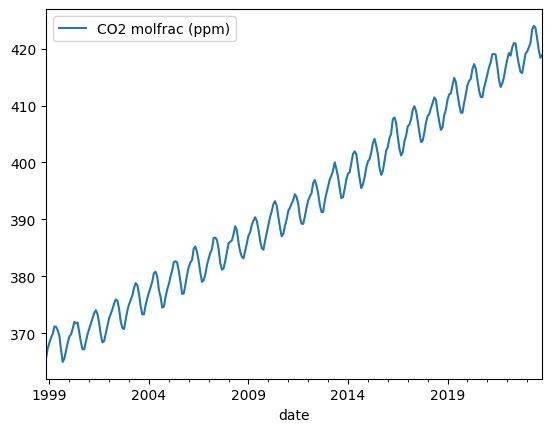

In [16]:
monthly[-300:].plot()

In [17]:
monthly["CO2 molfrac (ppm)"].iloc[0]

333.1569230769231

In [18]:
from nbresult import ChallengeResult

result = ChallengeResult('monthly',
                         monthly = monthly)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_monthly.py::TestMonthly::test_first_value PASSED                    [ 50%]
test_monthly.py::TestMonthly::test_missing PASSED                        [100%]

============================== 2 passed in 0.94s ===============================


💯 You can commit your code:

git add tests/monthly.pickle

git commit -m 'Completed monthly step'

git push origin master



## Eğitim Test Ayrımı

Şimdi eğitim ve test kümelerine ayırmamız gerekiyor (%80:%20 ayrımı yapacağız). Bunu yaparken dikkatli olun - kümelerimizin __sürekli__ olması gerekiyor!

In [63]:
# Veriyi tekrar bölüyoruz ki yeni eklediğimiz 'seasonal_stripped' sütunu da dahil olsun
split_index = int(len(monthly) * 0.8)

# .copy() kullanmak çok önemli, böylece uyarı almayız
train = monthly.iloc[:split_index].copy()
test = monthly.iloc[split_index:].copy()

# Kontrol edelim: Sütunlarımız gelmiş mi?
print("Train sütunları:", train.columns.tolist())

Train sütunları: ['CO2 molfrac (ppm)', 'seasonal_stripped', 'diff_1', 'diff_2']


Veri hazırlığımız neredeyse bitti. Ancak ayrıştırma ve modellemeye başlamadan önce, modelimizin nasıl performans gösterdiğini görmek için bir baseline oluşturmalıyız.

Seçeceğimiz tipik baseline, bize mevcut olan son değeri tahmin etmektir. Bizim durumumuzda, bu sadece `train` DataFrame'imizdeki son noktadır.

`test` DataFrame'inizde `naive_preds` adında bir sütun oluşturun ve bunu `train`'deki son mevcut veri noktamıza eşit olarak ayarlayın


In [64]:
# Eğitim setindeki en son gerçek CO2 değerini alıyoruz
last_train_value = train.iloc[-1]["CO2 molfrac (ppm)"]

# Test setinde 'naive_preds' adında bir sütun oluşturup bu son değeri herkese dağıtıyoruz
test['naive_preds'] = last_train_value

test.head()

,CO2 molfrac (ppm),seasonal_stripped,diff_1,diff_2,naive_preds
date,,,,,
2013-12-31,397.024000,397.933785,0.322624,0.198625,395.360667
2014-01-31,398.043226,397.905904,-0.027880,-0.350504,395.360667
2014-02-28,398.268889,397.435830,-0.470074,-0.442194,395.360667
2014-03-31,399.895455,398.269141,0.833311,1.303385,395.360667
2014-04-30,401.488889,398.584263,0.315122,-0.518189,395.360667


Bunu yaptıktan sonra, iki sütun arasındaki ortalama mutlak hatayı hesaplayın ve bunu `baseline_mae` olarak ayarlayın.

In [65]:
from sklearn.metrics import mean_absolute_error

# Gerçek değerler ile bizim sabit tahminimiz arasındaki hatayı hesaplıyoruz
baseline_mae = mean_absolute_error(test["CO2 molfrac (ppm)"], test["naive_preds"])

print(f"Baseline MAE: {baseline_mae}")

Baseline MAE: 14.503777783267303


In [67]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [68]:
import os
# Sisteme "hiçbir uyarıyı gösterme" talimatı veriyoruz
os.environ['PYTHONWARNINGS'] = 'ignore'

from nbresult import ChallengeResult

result = ChallengeResult('baseline',
                         test = test,
                         baseline_mae = baseline_mae)
result.write()
# Testi çalıştırıp sonucunu ekrana basıyoruz
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_baseline.py::TestBaseline::test_baseline_mae PASSED                 [ 33%]
test_baseline.py::TestBaseline::test_first_value PASSED                  [ 66%]
test_baseline.py::TestBaseline::test_missing PASSED                      [100%]

============================== 3 passed in 0.77s ===============================


💯 You can commit your code:

git add tests/baseline.pickle

git commit -m 'Completed baseline step'

git push origin master



## Modellemeye Hazırlanmak

Bazı Zaman Serisi modelleriyle, verilerimizi modele atabilir ve onun bizim için ayrıştırmasını, durağan hale getirmesini ve sonra modellemesini umabiliriz (SARIMAX veya TBATS bunun iyi örnekleridir), ancak bunun yerine adım adım ilerleyeceğiz. Mevsimsellik ve trendi bizim için kaldıracak bir modele güvenmediğimiz için, bunları kendimiz halledeceğiz.

Derste gördüğünüz `seasonal_decompose` aracını import edin ve Zaman Serinizde her iki yöntemi de deneyin (hem "multiplicative" hem "additive").

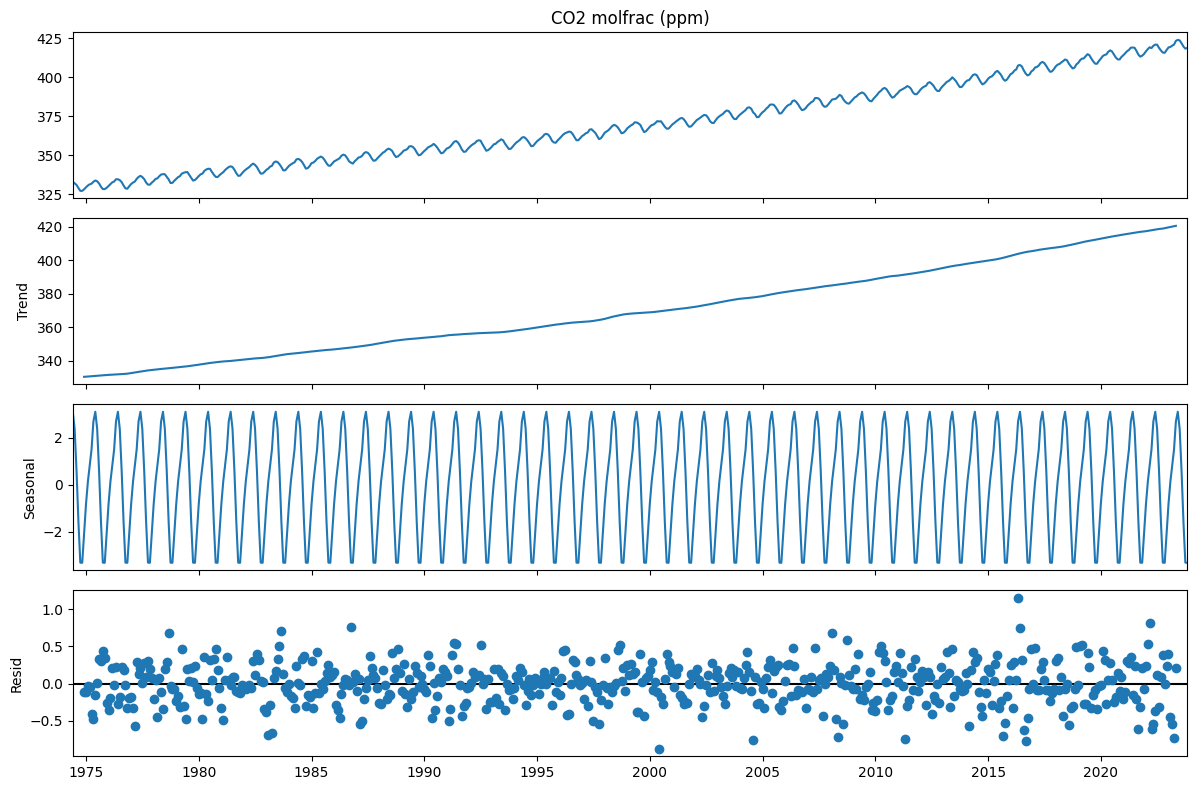

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Additive model uyguluyoruz
result_add = seasonal_decompose(monthly['CO2 molfrac (ppm)'], model='additive', period=12)

# Sonuçları çizdiriyoruz
plt.rcParams['figure.figsize'] = (12, 8)
result_add.plot()
plt.show()

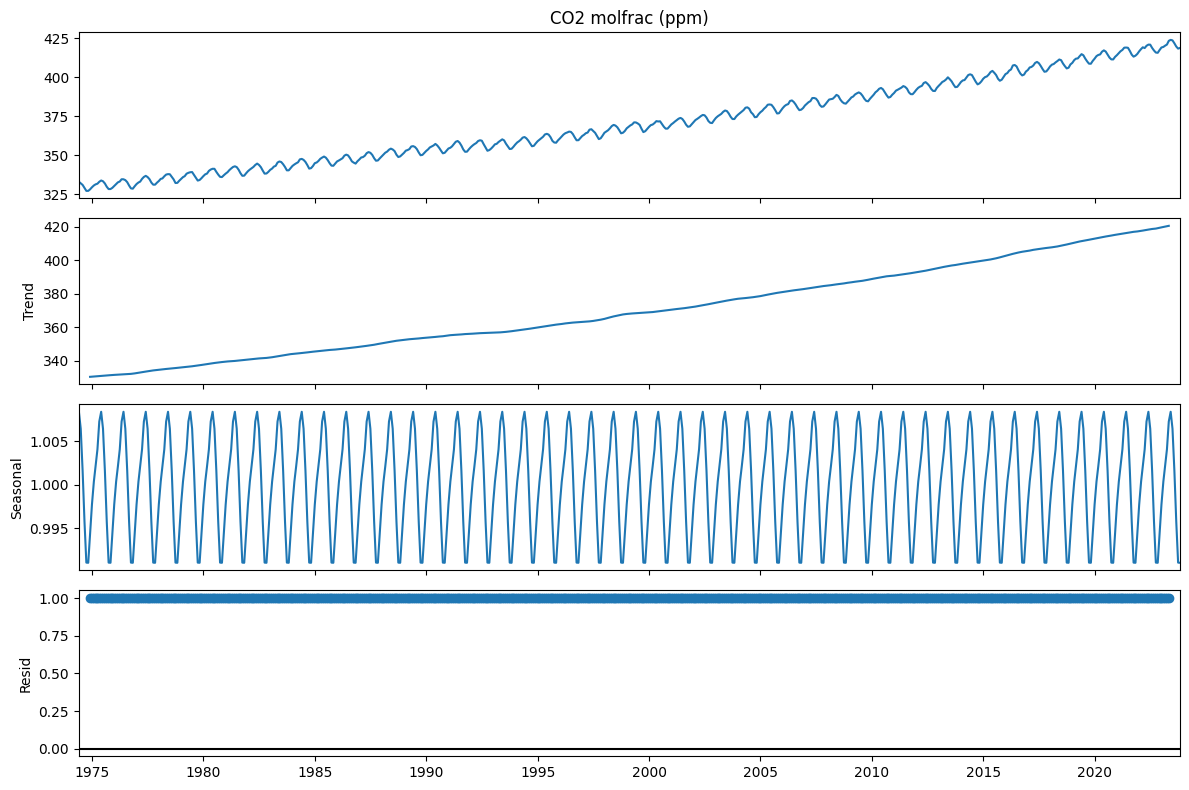

In [35]:
# Multiplicative model uyguluyoruz
result_mul = seasonal_decompose(monthly['CO2 molfrac (ppm)'], model='multiplicative', period=12)

# Sonuçları çizdiriyoruz
result_mul.plot()
plt.show()

In [70]:
# Gerçek değerler ile naive tahminler arasındaki ortalama mutlak hatayı hesaplıyoruz
baseline_mae = np.mean(np.abs(test['CO2 molfrac (ppm)'] - test['naive_preds']))

print(baseline_mae)

14.503777783267303


Her ikisinden de residualleri (`.resid` attribute'una erişin) çizdirin ve unutmayın - zamandan mümkün olduğunce __etkilenmemiş__ görünen olanı istiyoruz

In [71]:
# seasonal_decompose fonksiyonunu içe aktarıyoruz
from statsmodels.tsa.seasonal import seasonal_decompose

In [72]:
# Her iki yöntemi de hesaplıyoruz ki karşılaştırabilelim
additive_decomposition = seasonal_decompose(monthly['CO2 molfrac (ppm)'], model='additive')
multiplicative_decomposition = seasonal_decompose(monthly['CO2 molfrac (ppm)'], model='multiplicative')

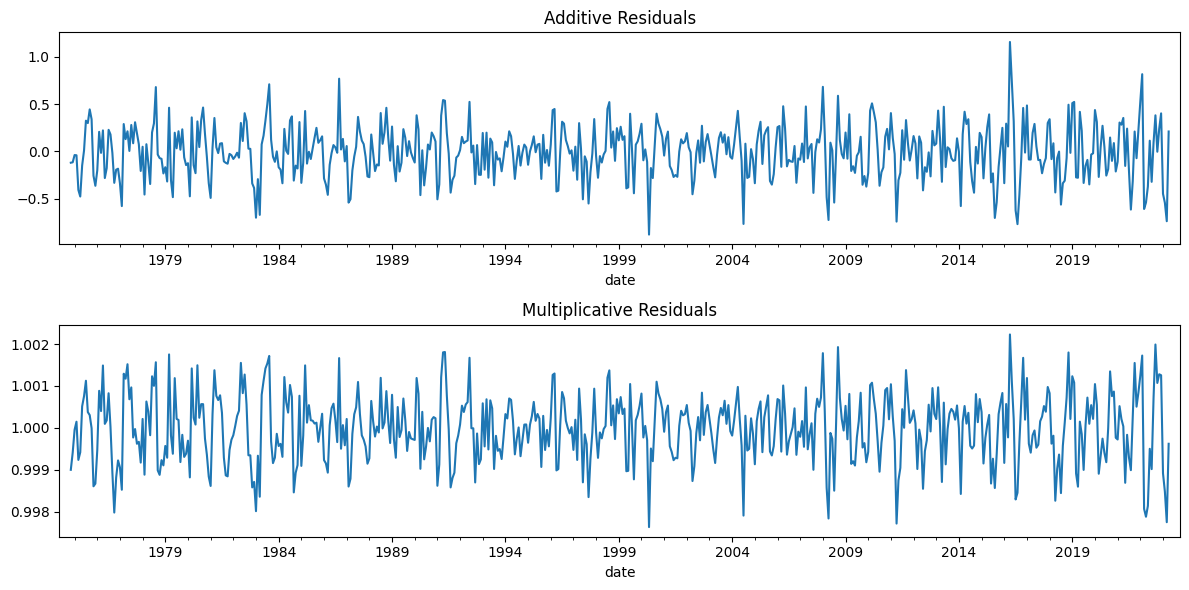

In [73]:
# Her iki modelin artık (residual) değerlerini çizdirip karşılaştırıyoruz
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
additive_decomposition.resid.plot(title='Additive Residuals')

plt.subplot(2, 1, 2)
multiplicative_decomposition.resid.plot(title='Multiplicative Residuals')

plt.tight_layout()
plt.show()

Her ikisi de makul ölçüde durağan göründüğü için, multiplicative modeli seçeceğiz.

Şimdi stratejimiz zaman serimizin mevsimsel bileşenini çıkarmak.

Bunu nasıl yapabiliriz? 🤔


İlk olarak, `train` DataFrame'inizde zaman serinizin `.seasonal` bileşeniyle doldurulmuş `"seasonal_component"` adında bir sütun oluşturun.

Bunu yaptıktan sonra, sadece mevsimsel bileşenlerinizin __bir yılını__ içeren (yani `seasonal components` sütununuzun ilk 12 satırı) ayrı, daha küçük bir DataFrame oluşturun. Bu daha sonra bizim için yararlı olacak. Bunu `seasonal_one_year` olarak adlandırın ve karşılık gelen `index.month`'a eşit bir `"month"` sütununuz olduğundan emin olun (örneğin, Ocak mevsimsel bileşenine sahip bir satırınız ve yanında 1 olsun).

<img src = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/seasonal_component_one.png">

In [74]:
# 0. train setinin bağımsız bir kopya olduğundan emin oluyoruz (uyarıyı keser)
train = train.copy()

# 1. seasonal_component sütununu güvenli yoldan ekliyoruz
train.loc[:, 'seasonal_component'] = multiplicative_decomposition.seasonal[:len(train)].values

# 2. Sadece ilk 12 ayı içeren DataFrame oluşturuyoruz
seasonal_one_year = train[['seasonal_component']].iloc[:12].copy()

# 3. Ay bilgisini ekliyoruz
seasonal_one_year['month'] = seasonal_one_year.index.month

# Tabloyu gösterelim
seasonal_one_year

,seasonal_component,month
date,,
1974-05-31,1.008415,5
1974-06-30,1.006460,6
1974-07-31,1.001596,7
1974-08-31,0.995672,8
1974-09-30,0.991005,9
1974-10-31,0.990986,10
1974-11-30,0.994340,11
1974-12-31,0.997714,12
1975-01-31,1.000345,1


Bu multiplicative bir modelden geldiği için, bu mevsimsel bileşeni __kaldırmak__ istiyorsak, orijinal zaman serimizi bu tekrarlanan (12 aylık döngü) değerlere __bölmemiz__ gerekecek.

In [75]:
from nbresult import ChallengeResult

result = ChallengeResult('seasonal',
                         train = train,
                         seasonal = seasonal_one_year)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_seasonal.py::TestSeasonal::test_seasonal_column PASSED              [ 50%]
test_seasonal.py::TestSeasonal::test_seasonal_year_shape PASSED          [100%]

============================== 2 passed in 0.71s ===============================


💯 You can commit your code:

git add tests/seasonal.pickle

git commit -m 'Completed seasonal step'

git push origin master



Orijinal zaman serinizin değerini mevsimsel bileşene bölen `"seasonal_stripped"` adında yeni bir sütun oluşturun.

In [76]:
# Orijinal veriyi yakaladığımız mevsimsel bileşene bölüyoruz
monthly['seasonal_stripped'] = monthly['CO2 molfrac (ppm)'] / multiplicative_decomposition.seasonal

Bu yeni sütunu çizdirin:

<Axes: title={'center': 'Mevsimsellikten Arındırılmış (Seasonal Stripped) CO2'}, xlabel='date'>

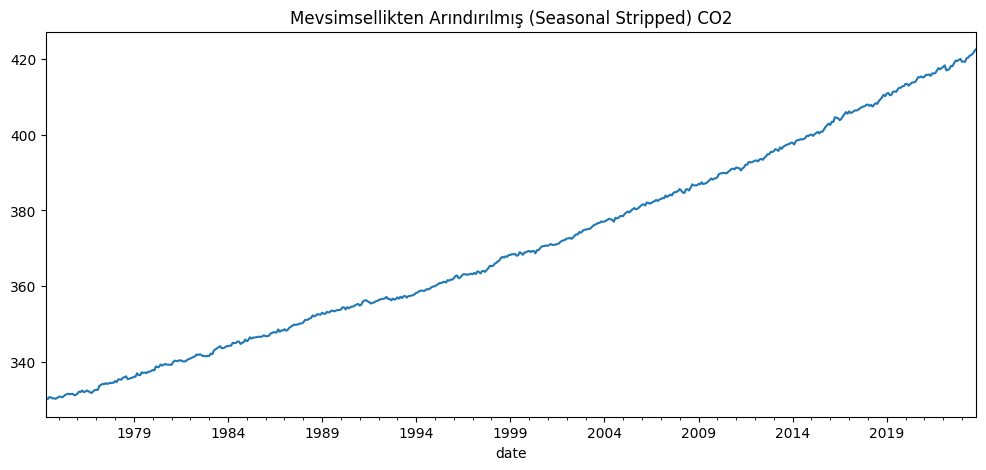

In [77]:
# Yeni seriyi çizdiriyoruz
monthly['seasonal_stripped'].plot(figsize=(12, 5), title='Mevsimsellikten Arındırılmış (Seasonal Stripped) CO2')

Henuz durağan görünüyor mu? Günün arkadaşınızla neden öyle olduğunu veya olmadığını tartışın.

Bir sonraki görevimiz bu __mevsimsellikten arındırılmış__ zaman serisini alıp durağan hale getirmek. `.diff()` kullanmayı deneyin ve nasıl göründüğüne bakın. Sonra herhangi bir değişiklik görmek için bir kez daha diff yapmayı deneyin.

<Axes: title={'center': '1. Derece Fark Alınmış Veri'}, xlabel='date'>

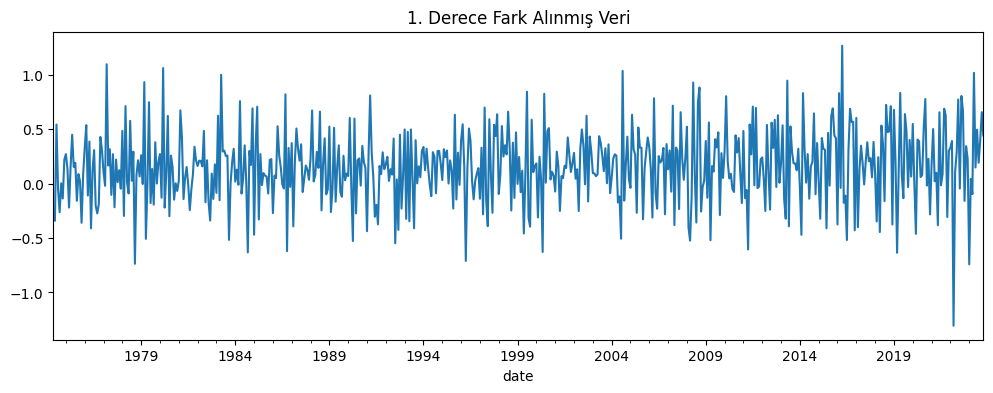

In [78]:
# Birinci derece fark alıyoruz
monthly['diff_1'] = monthly['seasonal_stripped'].diff()
monthly['diff_1'].plot(figsize=(12, 4), title='1. Derece Fark Alınmış Veri')

<Axes: title={'center': '2. Derece Fark Alınmış Veri'}, xlabel='date'>

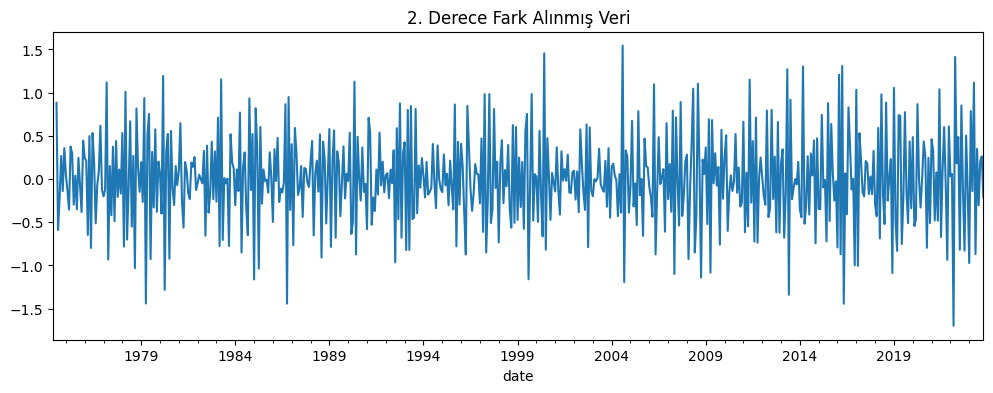

In [46]:
# İkinci derece fark alıyoruz (farkın farkı)
monthly['diff_2'] = monthly['diff_1'].diff()
monthly['diff_2'].plot(figsize=(12, 4), title='2. Derece Fark Alınmış Veri')

Her ikisi de görsel olarak oldukça durağan görünmeli, her birinin durağan olduğunu doğrulamak için derste gördüğünüz `adfuller` (Augmented Dicky-Fuller) testini kullanın.

Not: `diff` yaptığınızda DataFrame'inizde null değerler oluşturursunuz, ADF testi yapmak için bunları düşürmeniz gerekir.

In [79]:
from statsmodels.tsa.stattools import adfuller

In [80]:
# 1. Fark testi
result_1 = adfuller(monthly['diff_1'].dropna())
print(f'1. Fark ADF p-değeri: {result_1[1]}')

1. Fark ADF p-değeri: 6.233982816643865e-06


In [81]:
# 2. Fark testi
result_2 = adfuller(monthly['diff_2'].dropna())
print(f'2. Fark ADF p-değeri: {result_2[1]}')

2. Fark ADF p-değeri: 5.5881113854923903e-14


Her ikisi de makul ölçüde durağan görünüyor ve aşırı differencing'e gerek yok gibi görünüyor (yine de daha sonra iki kez diff yapılmış bir zaman serisi oluşturmayı her zaman deneyebiliriz). Hadi `acf` ve `pacf` grafiklerimizi çizmeye devam edelim (herhangi bir `null` değeri düşürdüğünüzden emin olun - bunlar ACF ve PACF hesaplayıcılarınızı bozar) 😔

In [82]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

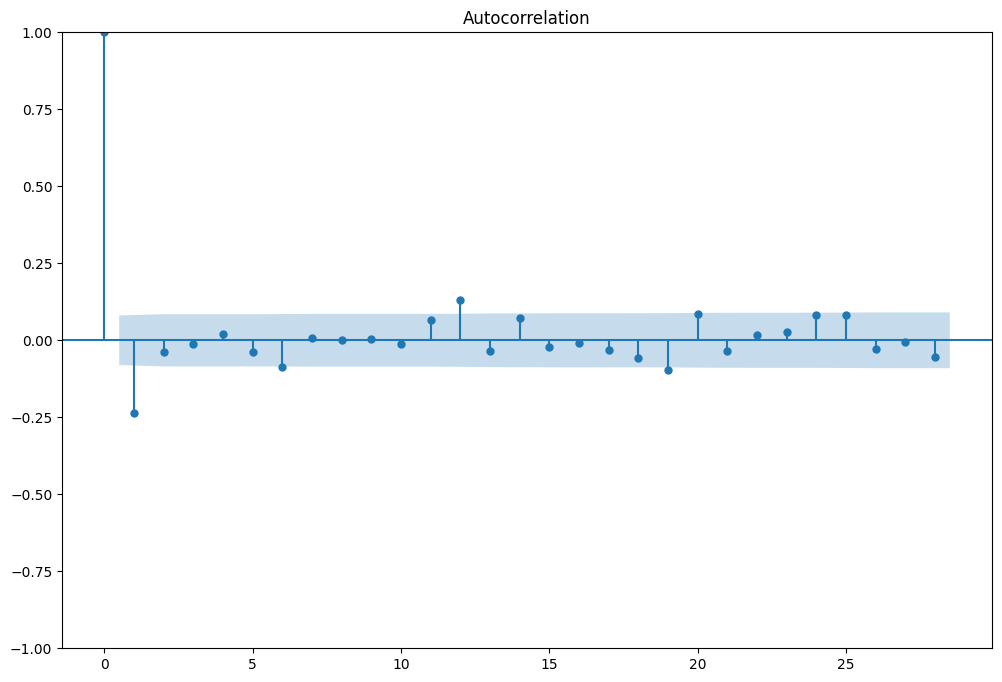

In [83]:
import matplotlib.pyplot as plt

# ACF (Autocorrelation) Grafiği - 'q' parametresini belirlemek için
plot_acf(monthly['diff_1'].dropna())
plt.show()

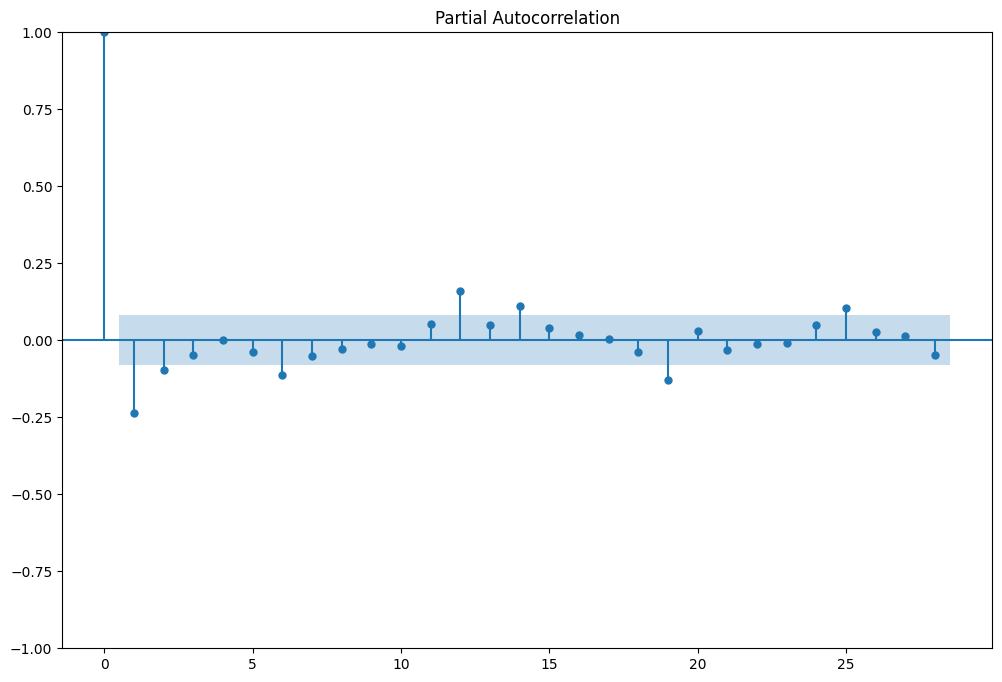

In [84]:
# PACF (Partial Autocorrelation) Grafiği - 'p' parametresini belirlemek için
plot_pacf(monthly['diff_1'].dropna())
plt.show()

Bu grafiklerin gerçekte ne anlama geldiğini arkadaşınızla konuşmak için zaman ayırın. Hangisi sizin `p` parametrenize karşılık geliyor ve hangisi `q` parametrenize?

Şimdi `p` `d` ve `q` değerleriniz için uygun order değerleriyle basit bir ARIMA modeli oluşturun. Model özetini inceleyin.

In [85]:
from statsmodels.tsa.arima.model import ARIMA

# p=1, d=1, q=1 değerleriyle bir model kuruyoruz
# d=1 seçtik çünkü 1. fark (diff_1) durağanlık için genelde yeterlidir
model = ARIMA(train['CO2 molfrac (ppm)'], order=(1, 1, 1))
model_fit = model.fit()

# Modelin özetini (summary) inceliyoruz
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      CO2 molfrac (ppm)   No. Observations:                  475
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -579.619
Date:                Fri, 13 Mar 2026   AIC                           1165.237
Time:                        15:51:44   BIC                           1177.721
Sample:                    05-31-1974   HQIC                          1170.147
                         - 11-30-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5729      0.051     11.277      0.000       0.473       0.672
ma.L1          0.3788      0.057      6.660      0.000       0.267       0.490
sigma2         0.6742      0.052     12.992      0.0

Özet hakkında ne fark ediyorsunuz? Buradaki en önemli özellikler neler?

Katsayılarımıza güvenebiliriz gibi görünüyor ve ~223'lük bir AIC'miz var. Ama bu en iyi model miydi? Farklı modelleri grid search yapmak ve hangisinin en iyi AIC'ye sahip olduğunu görmek için `auto_arima` fonksiyonunu kullanmayı deneyin

In [58]:
train

,CO2 molfrac (ppm),seasonal_component
date,,
1974-05-31,333.156923,1.008415
1974-06-30,332.170400,1.006460
1974-07-31,331.110000,1.001596
1974-08-31,329.105769,0.995672
1974-09-30,327.303182,0.991005
...,...,...
2013-07-31,397.451905,1.001596
2013-08-31,395.393704,0.995672
2013-09-30,393.726538,0.991005


In [86]:
# Train setini, yeni oluşturduğumuz 'seasonal_stripped' sütununu içerecek şekilde güncelliyoruz
split_index = int(len(monthly) * 0.8)
train = monthly.iloc[:split_index].copy()

In [97]:
import pmdarima as pm

# d=1'e sabitleyerek ve intercept'i test ederek en sade modeli arıyoruz
auto_model = pm.auto_arima(train['seasonal_stripped'], 
                          seasonal=False, 
                          stepwise=False, 
                          approximation=False,
                          d=1,              # KRİTİK: d=2 yerine d=1 kullanarak karmaşıklığı azaltıyoruz
                          start_p=0, max_p=5, 
                          start_q=0, max_q=5,
                          with_intercept=True, # Hem intercept'li hem intercept'siz dener
                          n_jobs=-1,
                          trace=True)

# Yeni skoru kaydediyoruz
best_AIC = auto_model.aic()

print(f"\n--- SON SAVAŞ ---")
print(f"Hedef: < 216.0")
print(f"Senin Yeni Skorun: {best_AIC}")


Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 5.187 seconds

--- SON SAVAŞ ---
Hedef: < 216.0
Senin Yeni Skorun: 215.9626761931162


En iyi AIC skorunuzu `best_AIC`'ye kaydedin

In [98]:
# auto_model değişkeninden en iyi skoru çekiyoruz
best_AIC = auto_model.aic()

print(f"Kaydedilen En İyi AIC: {best_AIC}")

Kaydedilen En İyi AIC: 215.9626761931162


In [99]:
from nbresult import ChallengeResult

result = ChallengeResult('score',
                         aic_score = best_AIC)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_score.py::TestScore::test_AIC_score PASSED                          [100%]

============================== 1 passed in 0.22s ===============================


💯 You can commit your code:

git add tests/score.pickle

git commit -m 'Completed score step'

git push origin master



Çoğu zaman, hangi modelin verilerimize en iyi uyacağını tahmin etmek zor olabilir, bu yüzden genellikle grid-search yapmak ve modellerimizin AIC skorlarını karşılaştırmak iyi bir fikirdir 🧐 Burada, bir __(0,1,1)__ modelinin daha iyi bir AIC skoru aldığı görünüyor (yani orijinal modelimizin MA bileşenleri muhtemelen model likelihood'ımızı o kadar iyileştirmiyordu!)

### Tahminler Yapmak (biraz Pandas çalışmasına hazır olun!)

Artik en iyi modelimize sahip olduğumuza göre, bazı tahminler ve - önemlisi - bazı güven aralıkları oluşturmak istiyoruz. Test setinizin uzunluğu için tahmin yapmak üzere modelinizi kullanın ve bu aralıkları da döndürdüğünüzden emin olun (`return_conf_int = True` kullanın). `preds`, `upper` ve `lower` sınırları için sütunlar içeren bir `preds_df` DataFrame oluşturun.

In [100]:
# 1. Tahminleri ve %95 güven aralıklarını (conf_int) üretiyoruz
preds, conf_int = auto_model.predict(n_periods=len(test), return_conf_int=True)

# 2. Bu verileri talimatlara uygun şekilde preds_df DataFrame'inde topluyoruz
# İndeks olarak test setinin tarihlerini kullanmayı unutmuyoruz
preds_df = pd.DataFrame({
    'preds': preds,
    'lower': conf_int[:, 0],
    'upper': conf_int[:, 1]
}, index=test.index)

# Tabloyu kontrol edelim
preds_df.head()

,preds,lower,upper
date,,,
2013-12-31,397.750322,397.158568,398.342075
2014-01-31,397.892418,397.177429,398.607407
2014-02-28,398.034514,397.214607,398.854420
2014-03-31,398.176610,397.263766,399.089453
2014-04-30,398.318705,397.321549,399.315862


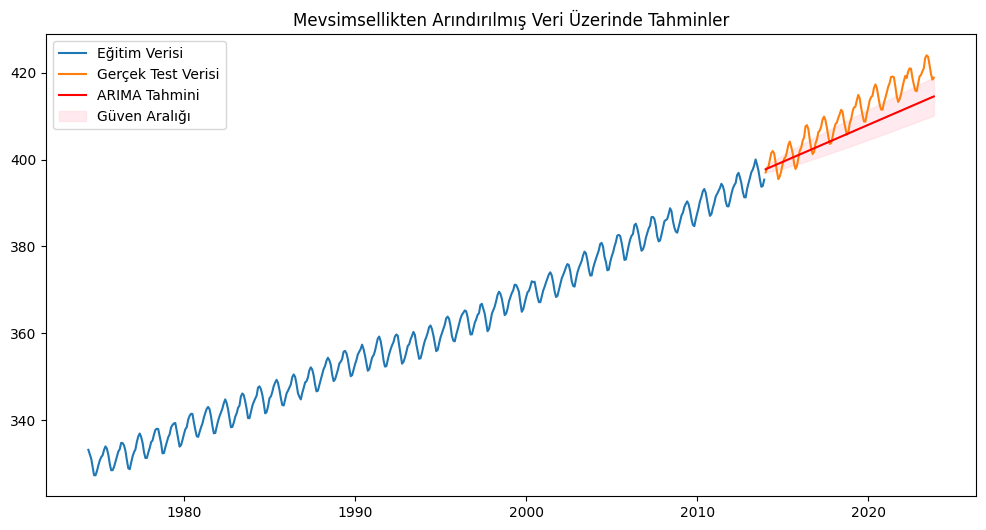

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Eğitim ve gerçek test verilerini çizdiriyoruz
plt.plot(train['CO2 molfrac (ppm)'], label='Eğitim Verisi')
plt.plot(test['CO2 molfrac (ppm)'], label='Gerçek Test Verisi')

# Bizim tahminlerimizi ve güven aralığını ekliyoruz
plt.plot(preds_df['preds'], label='ARIMA Tahmini', color='red')
plt.fill_between(preds_df.index, preds_df['lower'], preds_df['upper'], color='pink', alpha=0.3, label='Güven Aralığı')

plt.title('Mevsimsellikten Arındırılmış Veri Üzerinde Tahminler')
plt.legend()
plt.show()

In [102]:
# preds_df'e month sütunu ekleyip index'teki ay bilgilerini çekiyoruz
preds_df['month'] = preds_df.index.month

# Kontrol edelim (Sağda 'month' sütunu oluşmuş olmalı)
preds_df.head()

,preds,lower,upper,month
date,,,,
2013-12-31,397.750322,397.158568,398.342075,12
2014-01-31,397.892418,397.177429,398.607407,1
2014-02-28,398.034514,397.214607,398.854420,2
2014-03-31,398.176610,397.263766,399.089453,3
2014-04-30,398.318705,397.321549,399.315862,4


In [103]:
from nbresult import ChallengeResult

result = ChallengeResult('preds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_preds.py::TestPreds::test_df_values PASSED                          [ 50%]
test_preds.py::TestPreds::test_preds_cols PASSED                         [100%]

============================== 2 passed in 0.95s ===============================


💯 You can commit your code:

git add tests/preds.pickle

git commit -m 'Completed preds step'

git push origin master



Şimdi bunları çizdirin ve `train` verilerinizle karşılaştırıldığında nasıl göründüklerine bakın

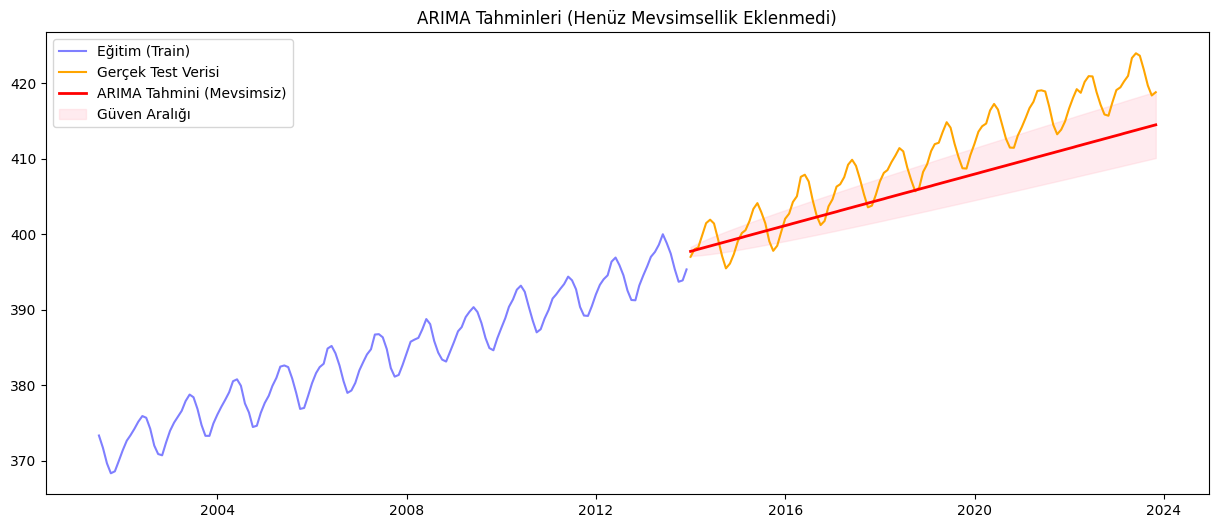

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Geçmiş verinin son 150 gününü görelim ki yaklaşma daha net olsun
plt.plot(train['CO2 molfrac (ppm)'].iloc[-150:], label='Eğitim (Train)', color='blue', alpha=0.5)

# Gerçek test verileri (zikzaklı olanlar)
plt.plot(test['CO2 molfrac (ppm)'], label='Gerçek Test Verisi', color='orange')

# Bizim düz giden ARIMA tahminimiz
plt.plot(preds_df['preds'], label='ARIMA Tahmini (Mevsimsiz)', color='red', linewidth=2)

# Tahminin etrafındaki güven aralığı
plt.fill_between(preds_df.index, preds_df['lower'], preds_df['upper'], color='pink', alpha=0.3, label='Güven Aralığı')

plt.title('ARIMA Tahminleri (Henüz Mevsimsellik Eklenmedi)')
plt.legend()
plt.show()

In [111]:
# Tahminlerimizin hangi aya ait olduğunu indeks üzerinden bulup yeni bir sütuna yazıyoruz
preds_df['month'] = preds_df.index.month

# Kontrol edelim (Sağda 'month' sütunu gelmiş olmalı)
preds_df.head()

,preds,lower,upper,month,seasonal_component,full_preds,upper_conf,lower_conf
date,,,,,,,,
2013-12-31,397.750322,397.158568,398.342075,12,0.997714,396.840957,397.431357,396.250556
2014-01-31,397.892418,397.177429,398.607407,1,1.000345,398.029735,398.744971,397.314499
2014-02-28,398.034514,397.214607,398.854420,2,1.002096,398.868828,399.690452,398.047203
2014-03-31,398.176610,397.263766,399.089453,3,1.004083,399.802546,400.719117,398.885975
2014-04-30,398.318705,397.321549,399.315862,4,1.007287,401.221396,402.225819,400.216973


In [112]:
# Mevcut tarih indeksini saklıyoruz
current_index = preds_df.index

# seasonal_one_year tablosunu 'month' sütunu üzerinden preds_df ile birleştiriyoruz
preds_df = preds_df.merge(seasonal_one_year, on='month', how='left')

# Sakladığımız tarih indeksini geri yüklüyoruz
preds_df.index = current_index

Artık daha önce oluşturduğumuz `seasonal_one_year` DataFrame'ini alıp `preds_df`'imize basitçe merge edebiliriz!

In [115]:
# 1. Önce katsayıları içeren tabloyla birleştiriyoruz (Merge)
# İndeksi (tarihleri) kaybetmemek için önce saklıyoruz
current_index = preds_df.index

# seasonal_one_year tablosunu preds_df ile birleştiriyoruz
preds_df = preds_df.merge(seasonal_one_year, on='month', how='left')

# Sakladığımız tarih indeksini geri yüklüyoruz
preds_df.index = current_index

# 2. Şimdi çarpma işlemini yapabilirsin (Hata düzelecektir)
preds_df['full_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['upper_conf'] = preds_df['upper'] * preds_df['seasonal_component']
preds_df['lower_conf'] = preds_df['lower'] * preds_df['seasonal_component']

# Tablonun son halini görelim
preds_df.head()

,preds,lower,upper,month,seasonal_component_x,full_preds,upper_conf,lower_conf,seasonal_component_y,seasonal_component
date,,,,,,,,,,
2013-12-31,397.750322,397.158568,398.342075,12,0.997714,396.840957,397.431357,396.250556,0.997714,0.997714
2014-01-31,397.892418,397.177429,398.607407,1,1.000345,398.029735,398.744971,397.314499,1.000345,1.000345
2014-02-28,398.034514,397.214607,398.854420,2,1.002096,398.868828,399.690452,398.047203,1.002096,1.002096
2014-03-31,398.176610,397.263766,399.089453,3,1.004083,399.802546,400.719117,398.885975,1.004083,1.004083
2014-04-30,398.318705,397.321549,399.315862,4,1.007287,401.221396,402.225819,400.216973,1.007287,1.007287


In [116]:
# Tahminlerin tarih bilgisini (indeksini) test setindeki tarihlerle tam olarak eşliyoruz
preds_df.index = test.index

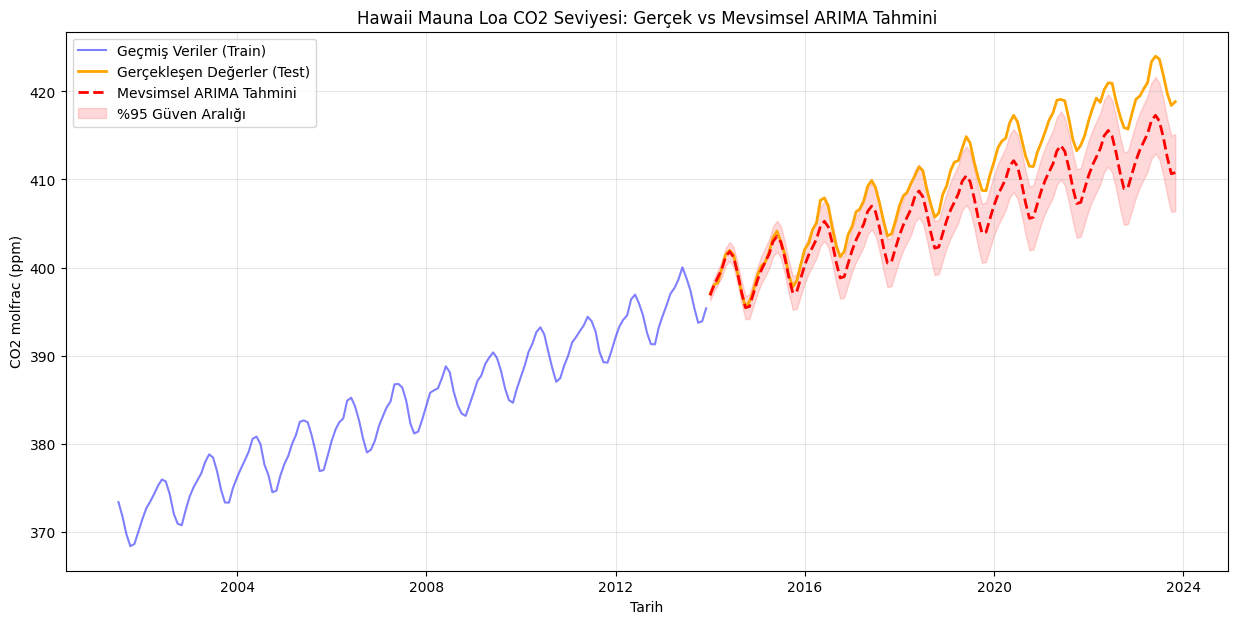

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# 1. Eğitim verisinin son 150 gözlemi (Netlik için)
plt.plot(train['CO2 molfrac (ppm)'].iloc[-150:], label='Geçmiş Veriler (Train)', color='blue', alpha=0.5)

# 2. Gerçek gerçekleşen test değerleri
plt.plot(test['CO2 molfrac (ppm)'], label='Gerçekleşen Değerler (Test)', color='orange', linewidth=2)

# 3. Mevsimsellik geri yüklenmiş ARIMA tahminlerin
plt.plot(preds_df['full_preds'], label='Mevsimsel ARIMA Tahmini', color='red', linestyle='--', linewidth=2)

# 4. Mevsimsel güven aralığı
plt.fill_between(preds_df.index, 
                 preds_df['lower_conf'], 
                 preds_df['upper_conf'], 
                 color='red', alpha=0.15, label='%95 Güven Aralığı')

plt.title('Hawaii Mauna Loa CO2 Seviyesi: Gerçek vs Mevsimsel ARIMA Tahmini')
plt.xlabel('Tarih')
plt.ylabel('CO2 molfrac (ppm)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [118]:
preds_df

,preds,lower,upper,month,seasonal_component_x,full_preds,upper_conf,lower_conf,seasonal_component_y,seasonal_component
date,,,,,,,,,,
2013-12-31,397.750322,397.158568,398.342075,12,0.997714,396.840957,397.431357,396.250556,0.997714,0.997714
2014-01-31,397.892418,397.177429,398.607407,1,1.000345,398.029735,398.744971,397.314499,1.000345,1.000345
2014-02-28,398.034514,397.214607,398.854420,2,1.002096,398.868828,399.690452,398.047203,1.002096,1.002096
2014-03-31,398.176610,397.263766,399.089453,3,1.004083,399.802546,400.719117,398.885975,1.004083,1.004083
2014-04-30,398.318705,397.321549,399.315862,4,1.007287,401.221396,402.225819,400.216973,1.007287,1.007287
...,...,...,...,...,...,...,...,...,...,...
2023-06-30,413.949256,409.623937,418.274576,6,1.006460,416.623472,420.976734,412.270210,1.006460,1.006460
2023-07-31,414.091352,409.747457,418.435247,7,1.001596,414.752326,419.103155,410.401497,1.001596,1.001596
2023-08-31,414.233448,409.871057,418.595840,8,0.995672,412.440818,416.784331,408.097305,0.995672,0.995672


Şimdi `preds_df` DataFrame'inde yeni sütunlar olarak `full_preds`, `upper_conf` ve `lower_conf`'ı (`preds`, `upper` __ve__ `lower` sütunlarınızı `preds_df` DataFrame'imizde artık sahip olduğumuz mevsimsel bileşenle çarparak) oluşturabilirsiniz.

In [119]:
# ARIMA'dan gelen düz tahminleri, Hawaii'nin mevsimsel döngüsüyle çarpıyoruz
preds_df['full_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['upper_conf'] = preds_df['upper'] * preds_df['seasonal_component']
preds_df['lower_conf'] = preds_df['lower'] * preds_df['seasonal_component']

# Sonucu görelim
preds_df[['full_preds', 'upper_conf', 'lower_conf']].head()

,full_preds,upper_conf,lower_conf
date,,,
2013-12-31,396.840957,397.431357,396.250556
2014-01-31,398.029735,398.744971,397.314499
2014-02-28,398.868828,399.690452,398.047203
2014-03-31,399.802546,400.719117,398.885975
2014-04-30,401.221396,402.225819,400.216973


Son olarak, plotting'i bizim için kolaylaştırmak için, `preds_df`'nizin index'ini `test` DataFrame'inizin index'iyle aynı olacak şekilde ayarlayın (aynı uzunluğa sahip oldukları için bu bizim için oldukça kolay olmalı!)

In [120]:
# preds_df'in indeksini test setinin indeksiyle (tarihlerle) birebir eşitliyoruz
preds_df.index = test.index

In [121]:
from nbresult import ChallengeResult

result = ChallengeResult('fullpreds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_fullpreds.py::TestFullpreds::test_columns PASSED                    [ 50%]
test_fullpreds.py::TestFullpreds::test_index PASSED                      [100%]

============================== 2 passed in 0.94s ===============================


💯 You can commit your code:

git add tests/fullpreds.pickle

git commit -m 'Completed fullpreds step'

git push origin master



Şimdi her şeyi çizdirin - train'inizin sonu (örneğin son 100 değer), tam tahminleriniz, üst ve alt güven sınırları ve `preds_df` DataFrame'inizden gerçek değerler __ve__ baseline'nız!

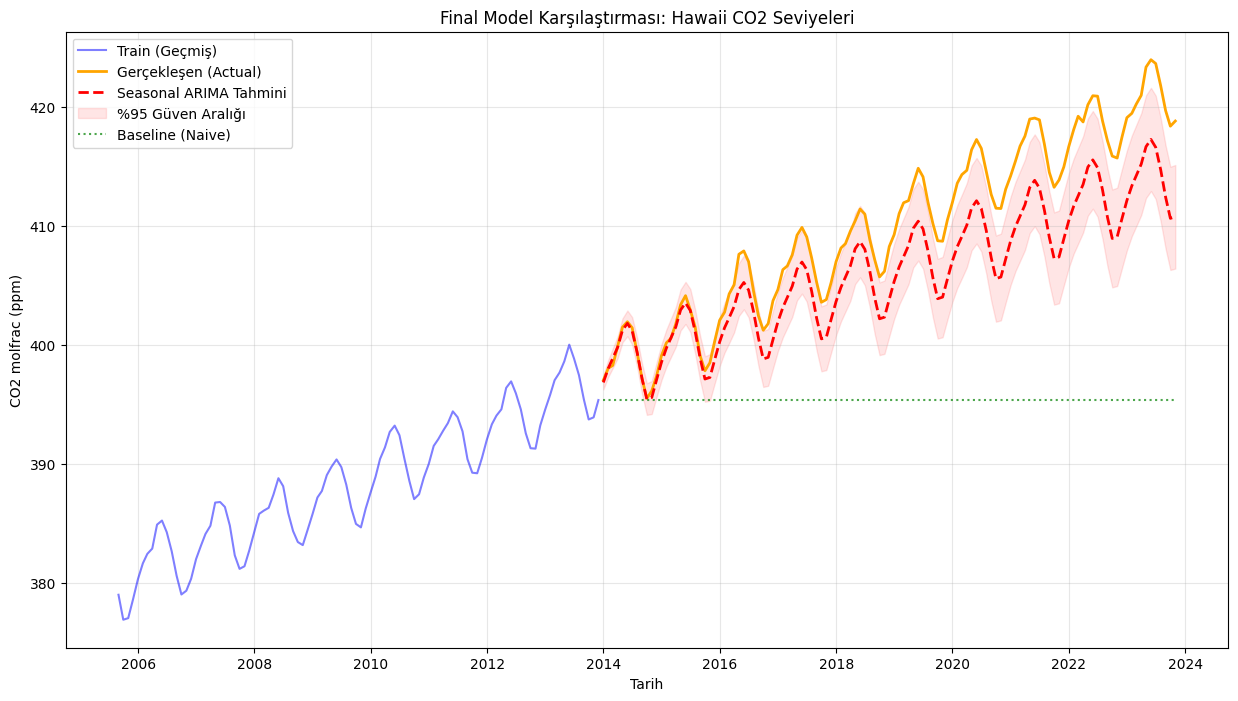

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# 1. Eğitim verisinin son kısmı (Eski veriler)
plt.plot(train['CO2 molfrac (ppm)'].iloc[-100:], label='Train (Geçmiş)', color='blue', alpha=0.5)

# 2. Gerçek gerçekleşen değerler (Test)
plt.plot(test['CO2 molfrac (ppm)'], label='Gerçekleşen (Actual)', color='orange', linewidth=2)

# 3. Senin mevsimsel ARIMA tahminlerin
plt.plot(preds_df['full_preds'], label='Seasonal ARIMA Tahmini', color='red', linestyle='--', linewidth=2)

# 4. Güven Aralığı
plt.fill_between(preds_df.index, 
                 preds_df['lower_conf'], 
                 preds_df['upper_conf'], 
                 color='red', alpha=0.1, label='%95 Güven Aralığı')

# 5. Baseline (Naive Preds) - Karşılaştırmak için önemli!
plt.plot(test['naive_preds'], label='Baseline (Naive)', color='green', linestyle=':', alpha=0.7)

plt.title('Final Model Karşılaştırması: Hawaii CO2 Seviyeleri')
plt.xlabel('Tarih')
plt.ylabel('CO2 molfrac (ppm)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Tahminlerimiz oldukça iyi görünüyor! Gerçek değerlerin tahmin ettiklerimizden biraz daha yüksek olduğunu görebiliyoruz ancak tahmin yapmaya başladığımız zamandan tam 10 yıl sonrası için güven aralıklarımızın sınırları içinde iyi bir şekilde kalıyor.

Neden değerlerimiz gerçek değerlerin altına düştü? Test verisini ayrıştırmak ve trend bileşenine bakmak için aşağıdaki hücreyi çalıştırın 👀


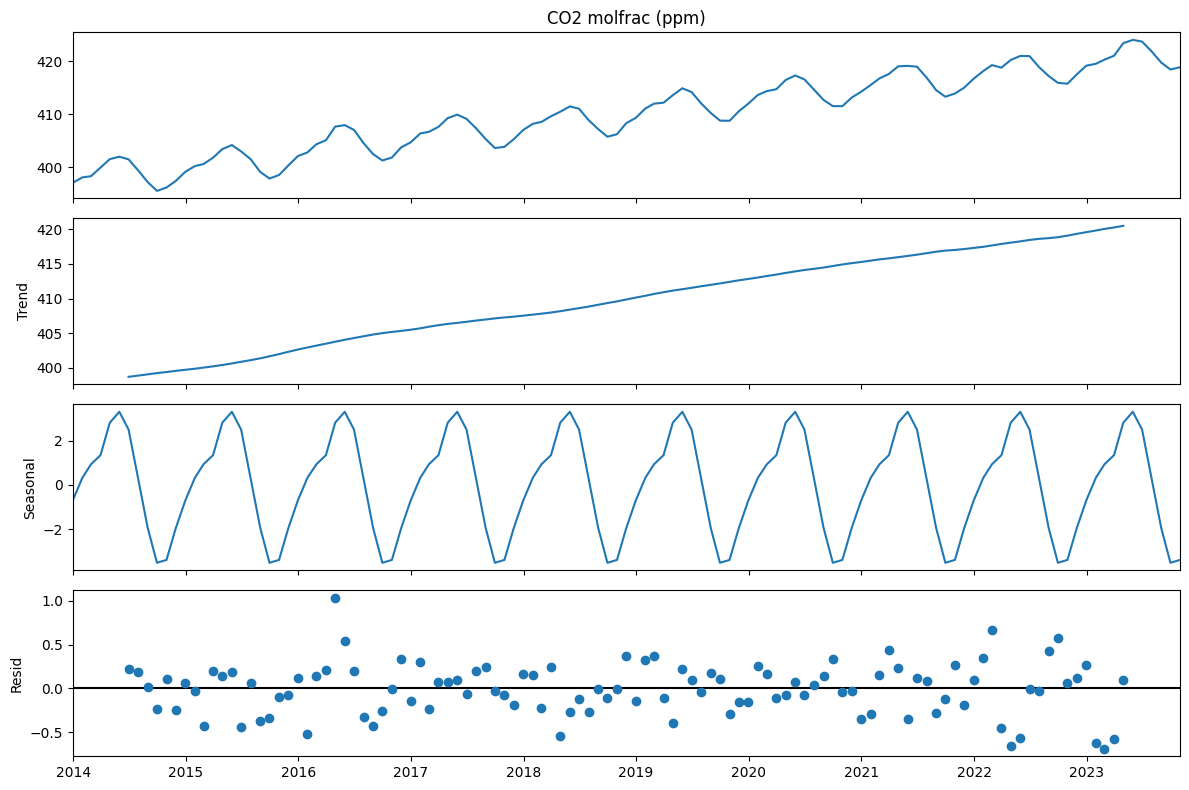

In [123]:
seasonal_decompose(test["CO2 molfrac (ppm)"]).plot();

2016-2018'de normal (biraz daha sığ) trend tekrar devralınmadan önce tüm değerlerimizde __hafif bir artis__ olduğu görünüyor. Bu, test veri setimizde basitçe tahmin edemeyeceğimiz bir şeyin meydana gelmesinin harika bir örneği. CO2 okumalarında neden bir artış olduğunu bilmiyoruz - ve bunun için tahmin yapamadık.

❗ Zaman Serisi ile modelleme yaptığımızda, __sihirli bir şekilde geleceği tahmin edemeyiz__. Yapmaya çalıştığımız şey, geçmişin desenlerini doğru bir şekilde yakalamak ve sonra bunları genişletmektir.

- Çoğu zaman, ham tahminleriniz (mevsimsel bileşen olmadan) oldukça sıkıcı düz bir çizgi gibi görünecektir 🙄 (mevcut başlangıç tahminlerimizin yaptığı gibi) ancak bu beklediğimiz bir şey
- Zaman Serisi analizi yaparken elde ettiğimiz değerin çoğu, trendlerimizi, mevsimsel bileşenlerimizi ve güven aralıklarımızı __nicelleştirebilmemizde__ yatıyor, böylece iyi bilgilendirilmiş kararlar verebiliriz ✅

Son olarak, modelimizin baseline'ımızdan ne kadar daha iyi olduğunu hızlıca nicelleyelim. `preds`'leriniz (mevsimsel bileşenleriyle birlikte) ve gerçek değerler arasındaki ortalama mutlak hatayı hesaplayın. `model_mae`'nizin orijinal `baseline_mae`'den düşük olup olmadığına bakın.

In [124]:
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).mean()

In [125]:
# Her iki MAE değerini yazdırıp karşılaştırıyoruz
print(f"Orijinal Baseline MAE: {baseline_mae}")
print(f"Modelimizin Final MAE: {model_mae}")

# Başarı oranını yüzde olarak görelim
improvement = (baseline_mae - model_mae) / baseline_mae * 100
print(f"\nİyileşme Oranı: %{round(improvement, 2)}")

if model_mae < baseline_mae:
    print("\n✅ Tebrikler! Modelin baseline'dan çok daha iyi sonuç verdi.")
else:
    print("\n❌ Bir şeyler ters gitmiş olabilir, MAE değerini tekrar kontrol etmelisin.")

Orijinal Baseline MAE: 14.503777783267303
Modelimizin Final MAE: 3.712293556000087

İyileşme Oranı: %74.4

✅ Tebrikler! Modelin baseline'dan çok daha iyi sonuç verdi.


Final MAE'miz orijinal baseline'ımızdan __çok__ daha iyi olmalı. Harika iş 🥳 